# Training the Segmentation Models

## Loading the database

In [1]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import numpy as np

IMG_SIZE = 512
BATCH_SIZE = 8
NUM_CLASSES = 1
CROP = "corn"  # "wheat", "sorghum", "corn"

dataset_path = f"../data/{CROP}/"

# --- Custom Dataset for Segmentation ---
class SegmentationDataset(Dataset):
    def __init__(self, root_dir, train=True):
        self.root_dir = root_dir
        self.train = train
        self.img_dir = os.path.join(root_dir, "train/images" if train else "test/images")
        self.mask_dir = os.path.join(root_dir, "train/masks" if train else "test/masks")

        self.image_files = sorted([
            f for f in os.listdir(self.img_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        self.mask_files = sorted([
            f for f in os.listdir(self.mask_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        assert len(self.image_files) == len(self.mask_files), \
            f"Image/Mask count mismatch: {len(self.image_files)} vs {len(self.mask_files)}"

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale mask

        # --- To Tensor ---
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

        # Mask → tensor (no normalization)
        mask = torch.from_numpy(np.array(mask)).float().unsqueeze(0)  # [1, H, W]
        mask = (mask > 0).float()

        return image, mask

# --- Datasets & Loaders ---
train_dataset = SegmentationDataset(dataset_path, train=True)
test_dataset = SegmentationDataset(dataset_path, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

✅ Train size: 16038 | Test size: 5346


In [2]:
for i in range(3):
    img, mask = train_dataset[i]
    print(img.shape, mask.shape)

torch.Size([3, 512, 512]) torch.Size([1, 512, 512])
torch.Size([3, 512, 512]) torch.Size([1, 512, 512])
torch.Size([3, 512, 512]) torch.Size([1, 512, 512])


## Importing Models

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


### UNET

In [3]:
import sys
sys.path.append('../')
from utils.models.uNet import UNet

channels = [32, 64, 128, 256, 512]
model = UNet(in_channels=3, out_channels=1, channels=channels, bilinear=True, use_batchnorm=True)
model.to(device)
modelName = "U-NET"

### DeepLabv3+

In [3]:
import sys
sys.path.append('../')
from utils.models.deeplabv3p import DeepLabV3Plus

model = DeepLabV3Plus(num_classes=1, output_stride=16, backbone_width_mult=1.0).to(device)
model.to(device)
modelName = "DeepLabV3Plus"

### SegFormer

In [3]:
import sys
sys.path.append('../')
from utils.models.SegFormer import segformer

model = segformer(in_channels = 3, num_classes = 1)
model.to(device)
modelName = "SegFormer"

c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


### SegNet

In [3]:
import sys
sys.path.append('../')
from utils.models.SegNet import segnet

model = segnet(in_channels=3, num_classes=1, pretrained=False)
model.to(device)
modelName = "SegNet"

### MaskFormer

In [3]:
import sys
sys.path.append('../')

from utils.models.maskFormer import MaskFormer
from utils.models.resnet101 import resnet101_backbone

resnet101 = resnet101_backbone()
model = MaskFormer(
    backbone=resnet101, 
    num_classes=1, 
    num_queries=5,          # Reduced from 10
    embed_dim=64,           # Reduced from 128  
    transformer_layers=1,   # Reduced from 2
    transformer_heads=2,    # Reduced from 4
    transformer_ffn_dim=256, # Reduced from 512
    return_binary=True
).to(device)
modelName = "MaskFormer"

c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


### General Info

In [4]:
print(model)
num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")

MaskFormer(
  (backbone): ResNetBackbone(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential

## Training

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [5]:
# --- Configuration ---
EPOCHS = 200
early_stopping_patience = 5
best_val_loss = float('inf') 
patience_counter = 0
scaler = torch.amp.GradScaler('cuda')

# --- Loss & Optimizer ---
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

checkpoint_path = os.path.join("../models/", CROP + "_" + modelName + "_seg.pt")
print(f"Model checkpoints will be saved to: {checkpoint_path}")

# --- Tracking ---
train_losses, val_losses = [], []

Model checkpoints will be saved to: ../models/corn_MaskFormer_seg.pt


In [6]:
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
else:
    print("No checkpoint found, training from scratch.")

No checkpoint found, training from scratch.


In [6]:
# --- Training Loop ---
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    with tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch") as tepoch:
        for inputs, labels in tepoch:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                    print("NaN or Inf in model outputs!")
                if torch.isnan(labels).any() or torch.isinf(labels).any():
                    print("NaN or Inf in labels!")
                if labels.sum() == 0:
                    print("Skipping batch with all empty masks")
                    continue
                loss = loss_fn(outputs, labels)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            tepoch.set_postfix(loss=running_loss / (len(tepoch)))
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        with tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Validation", unit="batch") as vepoch:
            for inputs, labels in vepoch:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                    if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                        print("NaN or Inf in model outputs!")
                    if torch.isnan(labels).any() or torch.isinf(labels).any():
                        print("NaN or Inf in labels!")
                    if labels.sum() == 0:
                        print("Skipping batch with all empty masks")
                        continue
                    loss = loss_fn(outputs, labels)
                    preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.numel()
                val_acc = val_correct / val_total if val_total > 0 else 0
                val_loss += loss.item()
                vepoch.set_postfix(loss=val_loss / (len(vepoch)))

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f}%")

    # --- Scheduler step (use validation loss) ---
    lr_scheduler.step(avg_val_loss)

    # --- Checkpointing ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"✅ Model improved (Val Loss={avg_val_loss:.3f}), saved to {checkpoint_path}")
    else:
        patience_counter += 1
        print(f"🔴 No improvement, patience counter: {patience_counter}")

    if patience_counter >= early_stopping_patience:
        print("🛑 Early stopping triggered!")
        break

Epoch 1/200:   0%|          | 0/2005 [00:00<?, ?batch/s]

Epoch 1/200 - Validation:  55%|█████▍    | 365/669 [01:41<01:27,  3.47batch/s, loss=0.347] 

Skipping batch with all empty masks


Epoch 1/200 - Validation: 100%|██████████| 669/669 [03:09<00:00,  3.54batch/s, loss=0.637]


Epoch 1 - Val Loss: 0.6367 - Val Acc: 0.9598%
✅ Model improved (Val Loss=0.637), saved to ../models/corn_MaskFormer_seg.pt


...

Epoch 11 - Val Loss: 0.6349 - Val Acc: 0.9745%
🔴 No improvement, patience counter: 4


Epoch 12/200 - Validation:  55%|█████▍    | 365/669 [01:40<01:24,  3.58batch/s, loss=0.346] 

Skipping batch with all empty masks


Epoch 12/200 - Validation: 100%|██████████| 669/669 [03:03<00:00,  3.64batch/s, loss=0.635]

Epoch 12 - Val Loss: 0.6349 - Val Acc: 0.9744%
🔴 No improvement, patience counter: 5
🛑 Early stopping triggered!


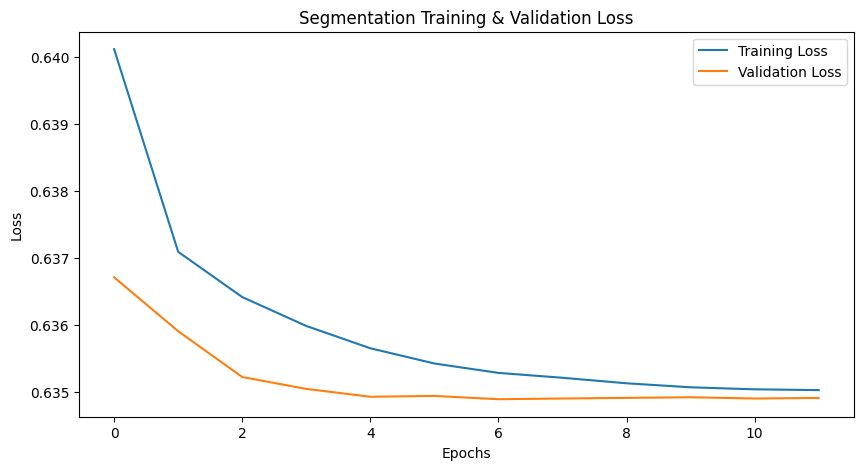

In [7]:
# --- Plot losses ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Segmentation Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Inference on Test Image

C:\Users\gnoceras\AppData\Local\Temp\ipykernel_20220\2977633742.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


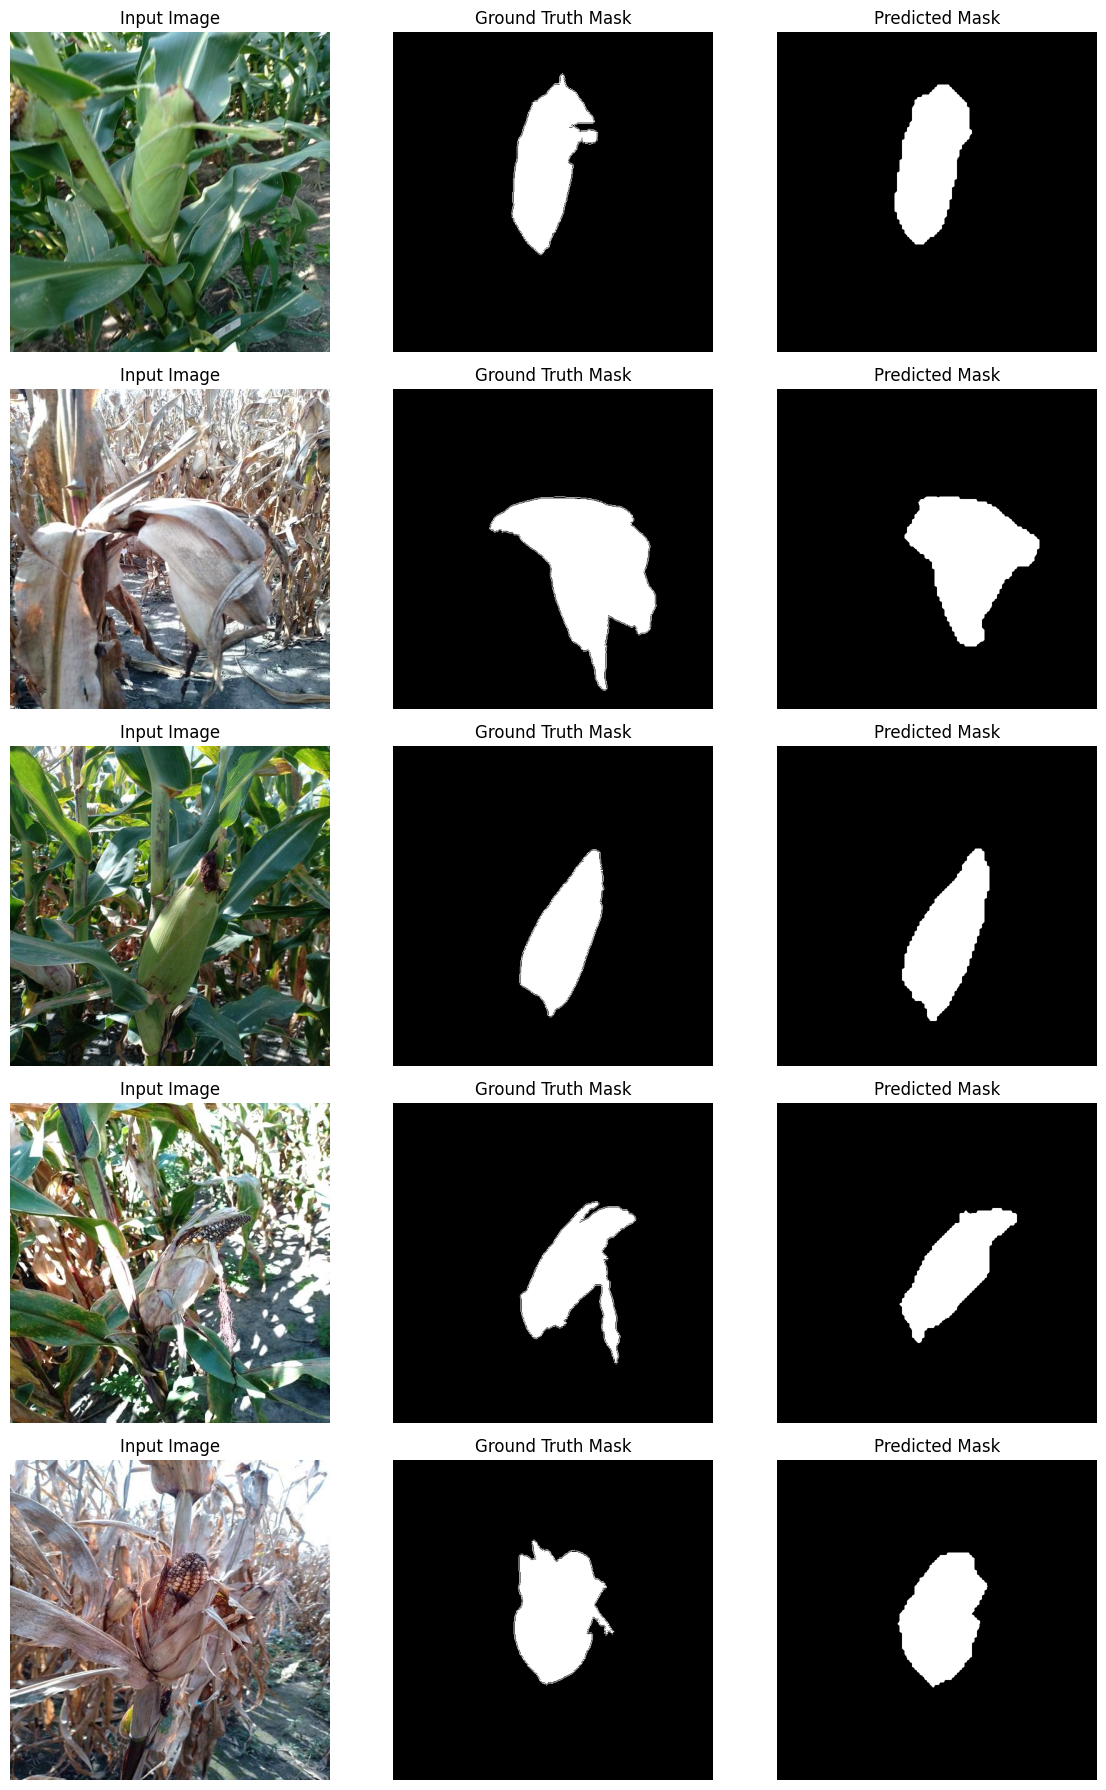

In [8]:
import random

# Pick 5 random indices from the test dataset
indices = random.sample(range(len(test_dataset)), 5)

fig, axs = plt.subplots(5, 3, figsize=(12, 18))
for i, idx in enumerate(indices):
    img, mask = test_dataset[idx]
    img_input = img.unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            pred_logits = model(img_input)
            pred_mask = (torch.sigmoid(pred_logits) > 0.5).float().cpu().squeeze().numpy()
    axs[i, 0].imshow(img.permute(1, 2, 0).cpu() * 0.5 + 0.5)
    axs[i, 0].set_title("Input Image")
    axs[i, 1].imshow(mask.squeeze().cpu(), cmap='gray')
    axs[i, 1].set_title("Ground Truth Mask")
    axs[i, 2].imshow(pred_mask, cmap='gray')
    axs[i, 2].set_title("Predicted Mask")
    for j in range(3):
        axs[i, j].axis('off')
plt.tight_layout()
plt.show()


In [9]:
import time
from PIL import Image
import torchvision.transforms.functional as TF

# --- Config ---
IMG_PATH = "../data/{}/test/images/1_1_4.jpg".format(CROP)  # <-- set your image path

model.eval()

# --- Preprocess image ---
img = Image.open(IMG_PATH).convert("RGB")
img = img.resize((512, 512))  # resize if needed
img_tensor = TF.to_tensor(img)
img_tensor = TF.normalize(img_tensor, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
img_tensor = img_tensor.unsqueeze(0).to(device)

# --- Inference with timing ---
with torch.no_grad():
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    start = time.time()
    with torch.cuda.amp.autocast():
        pred_logits = model(img_tensor)
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    end = time.time()
    pred_mask = (torch.sigmoid(pred_logits) > 0.5).float().cpu().squeeze().numpy()

print(f"Inference time: {end - start:.4f} seconds")

C:\Users\gnoceras\AppData\Local\Temp\ipykernel_20220\961485312.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Inference time: 0.2566 seconds
